# 1. Introduction
In today's digital landscape, recommender systems have become essential tools for enhancing user experience and driving engagement. By leveraging algorithms to analyze user behavior and preferences, these systems provide personalized content tailored to individual needs. Whether in e-commerce, streaming services, or social media, recommender systems help users discover relevant products, services, or information, influencing their decisions and improving satisfaction. The effectiveness of these systems not only boosts sales and customer loyalty but also creates a competitive advantage for businesses.

Hence, in this project, I will make use of Neural Network with Matrix Factorization and side information to predict the rating of a user will give on a certain movie, so as to give recommendation according to the predicted rating. The dataset used is an available rating data from the MovieLens website, a United State's movie platform. It contains around a hundred thousand ratings, with side information of users and movies. It is downloaded from GroupLens with notes on the usage, distribution and the information of the dataset.

The URL for the downloaded dataset is https://grouplens.org/datasets/movielens/.

# 2. Data Importing
The MovieLens dataset contains of 3 dat files. One for the side information of all users, one for movie and one for the rating given out. Based on the file structure, I use the following method to store the data in 3 Pandas dataframes.



# 3. Data Cleaning
The "movies.dat" file contains three columns: movie_id, title, and genres. Since the title includes a formatted year, I extracted the year into a new column. Additionally, because the title of a movie is unlikely to significantly influence its rating and an unnormalized string could complicate the model, I decided to drop the title column altogether.

In [1]:
import pandas as pd
with open('movies.dat', 'r', encoding='ISO-8859-1') as file:
    lines = file.readlines()
movie_data = []
for line in lines:
    movie_id, title, genres = line.strip().split('::')
    movie_data.append({
        'Movie ID': int(movie_id),
        'Title': title,
        'Genres': genres.split('|')
    })
movie_df = pd.DataFrame(movie_data)
movie_df['Year'] = movie_df['Title'].str.extract(r'\((\d{4})\)')
movie_df.drop(columns=['Title'], inplace=True)
print(movie_df.head())

   Movie ID                            Genres  Year
0         1   [Animation, Children's, Comedy]  1995
1         2  [Adventure, Children's, Fantasy]  1995
2         3                 [Comedy, Romance]  1995
3         4                   [Comedy, Drama]  1995
4         5                          [Comedy]  1995


In [2]:
na_counts = movie_df.isna().sum(axis=0) # Check the number of NA in each columns
print(na_counts)

Movie ID    0
Genres      0
Year        0
dtype: int64


In [3]:
print([min(movie_df['Movie ID']), max(movie_df['Movie ID'])]) # Study the pattern of Movie ID

[1, 3952]


The "ratings.dat" file contains three columns: user_id, movie_id, rating, and timestamp. No data cleaning work is needed.

In [4]:
from datetime import datetime
with open('ratings.dat', 'r', encoding='ISO-8859-1') as file:
    lines = file.readlines()
rating_data = []
for line in lines:
    user_id, movie_id, rating, timestamp = line.strip().split('::')
    rating_data.append({
        'User ID': int(user_id),
        'Movie ID': int(movie_id),
        'Rating': int(rating),
        'Timestamp': int(timestamp)
    })

rating_df = pd.DataFrame(rating_data)
print(rating_df.head())

   User ID  Movie ID  Rating  Timestamp
0        1      1193       5  978300760
1        1       661       3  978302109
2        1       914       3  978301968
3        1      3408       4  978300275
4        1      2355       5  978824291


In [5]:
na_counts = rating_df.isna().sum(axis=0)
print(na_counts)

User ID      0
Movie ID     0
Rating       0
Timestamp    0
dtype: int64


In [6]:
print([min(rating_df['Movie ID']), max(rating_df['Movie ID'])])

[1, 3952]


In [7]:
print([min(rating_df['User ID']), max(rating_df['User ID'])])

[1, 6040]


In [8]:
rating_df.shape

(1000209, 4)

The "users.dat" file contains five columns: user_id, gender, age, occupation and zipcode. Some of the zipcode will contain an extra extension after the generalized five number zipcode. Since there are only a few places will contain an extra extension, and the five number generalized zipcodes are specific enough, I have decided to drop any extension provided.

In [9]:
with open('users.dat', 'r', encoding='ISO-8859-1') as file:
    lines = file.readlines()
user_data = []
for line in lines:
    user_id, gender, age, occupation, zipcode = line.strip().split('::')
    user_data.append({
        'User ID': int(user_id),
        'Gender': gender,
        'Age': int(age),
        'Occupation': int(occupation),
        'Zipcode': int(zipcode.split('-')[0])
    })
user_df = pd.DataFrame(user_data)

print(user_df.head())

   User ID Gender  Age  Occupation  Zipcode
0        1      F    1          10    48067
1        2      M   56          16    70072
2        3      M   25          15    55117
3        4      M   45           7     2460
4        5      M   25          20    55455


We can discover some new variables to improve our model result. Since the number of rating given out by a user could significantly affect the "accuracy" of delivering their preference by rating, I have decided to add a new column "User ratings count".

In [10]:
user_rating_counts = rating_df['User ID'].value_counts()
user_df['User ratings count'] = user_df['User ID'].map(user_rating_counts).fillna(0).astype(int)
print(user_df.head(5))

   User ID Gender  Age  Occupation  Zipcode  User ratings count
0        1      F    1          10    48067                  53
1        2      M   56          16    70072                 129
2        3      M   25          15    55117                  51
3        4      M   45           7     2460                  21
4        5      M   25          20    55455                 198


In [11]:
na_counts = user_df.isna().sum(axis=0)
print(na_counts)

User ID               0
Gender                0
Age                   0
Occupation            0
Zipcode               0
User ratings count    0
dtype: int64


In [12]:
print([min(user_df['User ID']), max(user_df['User ID'])])

[1, 6040]


Meanwhile, the number of movies rating represent the popularity of a movie. If the movie was well-knowned among the people, the new rating given out may be affected by the major opinion. Hence, I have added a new column of "Movie ratings count".

In [13]:
movie_rating_counts = rating_df['Movie ID'].value_counts()
movie_df['Movie ratings count'] = movie_df['Movie ID'].map(movie_rating_counts).fillna(0).astype(int)
print(movie_df.head(5))

   Movie ID                            Genres  Year  Movie ratings count
0         1   [Animation, Children's, Comedy]  1995                 2077
1         2  [Adventure, Children's, Fantasy]  1995                  701
2         3                 [Comedy, Romance]  1995                  478
3         4                   [Comedy, Drama]  1995                  170
4         5                          [Comedy]  1995                  296


One may argue that the earlier rating given out is less affected by the popularity of the movie, or less accurate due to the lack of rating experience. My answer is yes and no. Usually, a larger number of ratings count could mean that the movie or the user have the experience of receiving or giving out the rating before the dataset record. Hence, in general, the result is less being affected.

Then, I tried to merge the 3 dataframes for the use of neural network modelling.

In [14]:
merged_user_ratings = pd.merge(rating_df, user_df, on='User ID', how='right')
df = pd.merge(merged_user_ratings, movie_df, on='Movie ID', how='right')
print(df.head(5))

   User ID  Movie ID  Rating    Timestamp Gender   Age  Occupation  Zipcode  \
0      1.0         1     5.0  978824268.0      F   1.0        10.0  48067.0   
1      6.0         1     4.0  978237008.0      F  50.0         9.0  55117.0   
2      8.0         1     4.0  978233496.0      M  25.0        12.0  11413.0   
3      9.0         1     5.0  978225952.0      M  25.0        17.0  61614.0   
4     10.0         1     5.0  978226474.0      F  35.0         1.0  95370.0   

   User ratings count                           Genres  Year  \
0                53.0  [Animation, Children's, Comedy]  1995   
1                71.0  [Animation, Children's, Comedy]  1995   
2               139.0  [Animation, Children's, Comedy]  1995   
3               106.0  [Animation, Children's, Comedy]  1995   
4               401.0  [Animation, Children's, Comedy]  1995   

   Movie ratings count  
0                 2077  
1                 2077  
2                 2077  
3                 2077  
4              

It is found that the number of rows in the merged dataframe is greater than that of the rating dataframe. Since some users or movies are unrated, it becomes a source of error in the modelling process. I have to remove the rows with "NA" in the dataframe.

In [15]:
df.shape

(1000386, 12)

In [16]:
df = df.dropna(subset=['Rating'])

In [17]:
df.shape

(1000209, 12)

In [18]:
na_counts = df.isna().sum(axis=0)
print(na_counts)

User ID                0
Movie ID               0
Rating                 0
Timestamp              0
Gender                 0
Age                    0
Occupation             0
Zipcode                0
User ratings count     0
Genres                 0
Year                   0
Movie ratings count    0
dtype: int64


In [19]:
print([min(df['User ID']), max(df['User ID'])])

[1.0, 6040.0]


In [20]:
print([min(df['Movie ID']), max(df['Movie ID'])])

[1, 3952]


During the process of merging the dataframes, some integers have been converted to float. It will also disturb the fitting of the model.

In [21]:
columns_to_convert = [
    'User ID',
    'Rating',
    'Timestamp',
    'Age',
    'Occupation',
    'Zipcode',
    'User ratings count',
    'Movie ratings count'
]

for col in columns_to_convert:
    df[col] = df[col].fillna(0).astype(int)
print(df.head(5))

   User ID  Movie ID  Rating  Timestamp Gender  Age  Occupation  Zipcode  \
0        1         1       5  978824268      F    1          10    48067   
1        6         1       4  978237008      F   50           9    55117   
2        8         1       4  978233496      M   25          12    11413   
3        9         1       5  978225952      M   25          17    61614   
4       10         1       5  978226474      F   35           1    95370   

   User ratings count                           Genres  Year  \
0                  53  [Animation, Children's, Comedy]  1995   
1                  71  [Animation, Children's, Comedy]  1995   
2                 139  [Animation, Children's, Comedy]  1995   
3                 106  [Animation, Children's, Comedy]  1995   
4                 401  [Animation, Children's, Comedy]  1995   

   Movie ratings count  
0                 2077  
1                 2077  
2                 2077  
3                 2077  
4                 2077  


In [22]:
max(df['User ID'])

6040

In [23]:
min(df['User ID'])

1

# 4. Exploratory Data Analysis

From the below graph, the average rating usually higher and converges to around 4 if an user have more experience in giving out rating. In other words, they are less likely giving out extreme rating. Hence, it is influential to the rating given out to a certain movie.

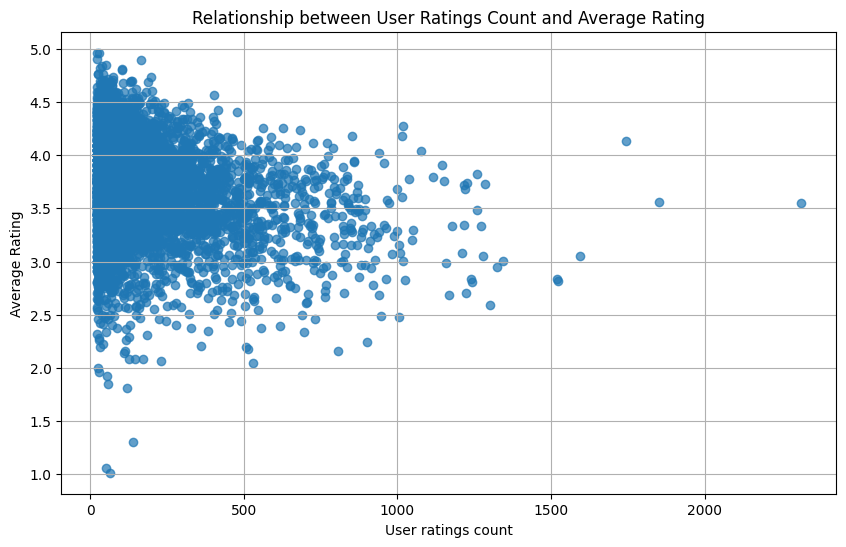

In [24]:
import matplotlib.pyplot as plt
average_ratings = rating_df.groupby('User ID')['Rating'].mean().reset_index()
merged_df = pd.merge(user_df, average_ratings, on='User ID', how='inner')
merged_df = merged_df[merged_df['User ratings count'] > 0]
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['User ratings count'], merged_df['Rating'], alpha=0.7)
plt.title('Relationship between User Ratings Count and Average Rating')
plt.xlabel('User ratings count')
plt.ylabel('Average Rating')
plt.grid()
plt.show()

The graph below shows that a higher rating is expected for a popular movie, as the rating given may be influenced by peers or societal expectations.

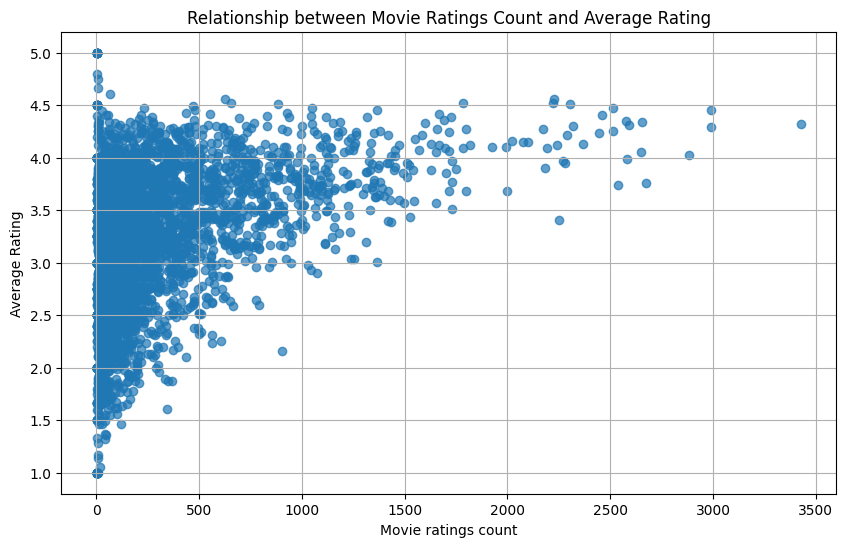

In [25]:
average_ratings = rating_df.groupby('Movie ID')['Rating'].mean().reset_index()
merged_df = pd.merge(movie_df, average_ratings, on='Movie ID', how='inner')
merged_df = merged_df[merged_df['Movie ratings count'] > 0]
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['Movie ratings count'], merged_df['Rating'], alpha=0.7)
plt.title('Relationship between Movie Ratings Count and Average Rating')
plt.xlabel('Movie ratings count')
plt.ylabel('Average Rating')
plt.grid()
plt.show()

From the graph below, the average rating varies every day and the dispersion increases at the latter stage. Hence, it is a continuous variable instead of categorical variable.

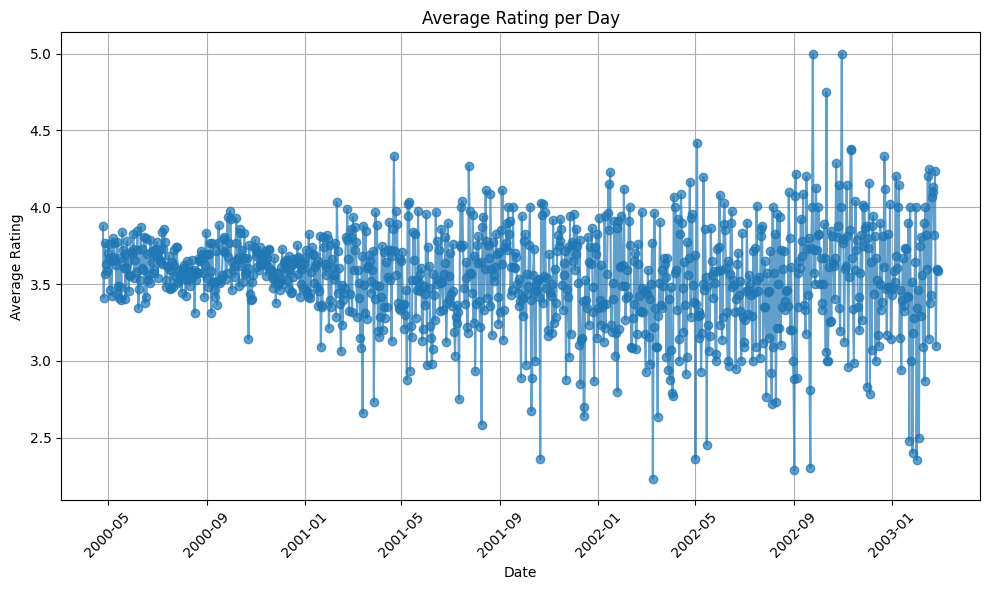

In [26]:
rating_df['date'] = pd.to_datetime(rating_df['Timestamp'], unit='s').dt.date
daily_avg = rating_df.groupby('date')['Rating'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(daily_avg['date'], daily_avg['Rating'], marker='o', linestyle='-', alpha=0.7)
plt.title('Average Rating per Day')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

It was found that there is no data for genders other than Male or Female, and that males tend to give slightly harsher ratings than females.

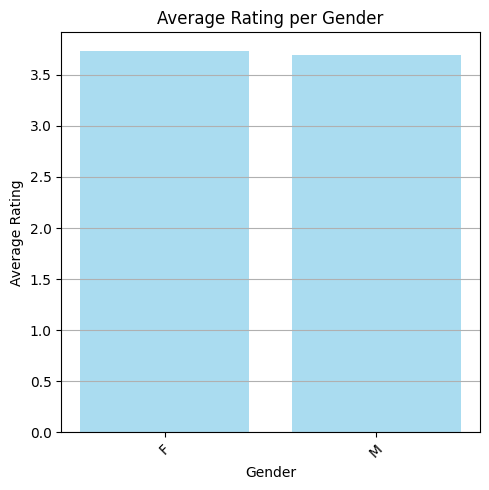

In [27]:
average_ratings = rating_df.groupby('User ID')['Rating'].mean().reset_index()
merged_df = pd.merge(user_df, average_ratings, on='User ID', how='inner')
merged_df['Gender'] = merged_df['Gender'].fillna('Unknown')
gender_avg = merged_df.groupby('Gender')['Rating'].mean().reset_index()
plt.figure(figsize=(5, 5))
plt.bar(gender_avg['Gender'], gender_avg['Rating'], color = 'skyblue', alpha=0.7)
plt.title('Average Rating per Gender')
plt.xlabel('Gender')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

From the graph below, only a few ages are available. This may be due to the limitation of data or privacy concern. Hence, age should be treated as a categorical variable. Also, we can observe that older people tends to give a higher rating.
The "Age" refers to the following ranges:

	*  1:  "Under 18"
	* 18:  "18-24"
	* 25:  "25-34"
	* 35:  "35-44"
	* 45:  "45-49"
	* 50:  "50-55"
	* 56:  "56+"

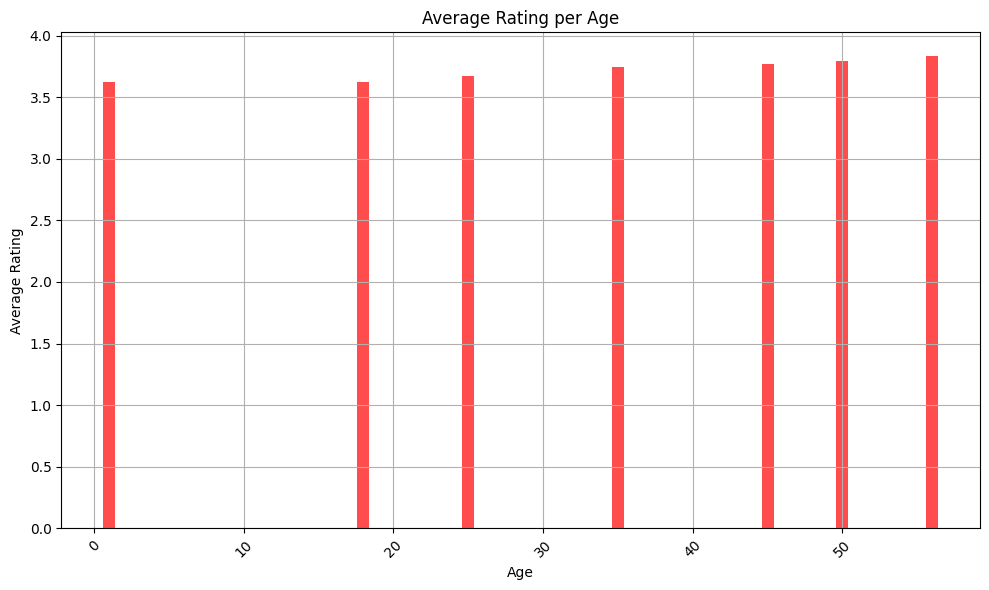

In [28]:
average_ratings = rating_df.groupby('User ID')['Rating'].mean().reset_index()
merged_df = pd.merge(user_df, average_ratings, on='User ID', how='inner')
age_avg = merged_df.groupby('Age')['Rating'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.bar(age_avg['Age'], age_avg['Rating'], color = 'red', alpha=0.7)
plt.title('Average Rating per Age')
plt.xlabel('Age')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

It is found that the type of occupation is represented by integers from 0 to 20, with different average ratings given.
Occupation refers to the following choices:

	*  0:  "other" or not specified
	*  1:  "academic/educator"
	*  2:  "artist"
	*  3:  "clerical/admin"
	*  4:  "college/grad student"
	*  5:  "customer service"
	*  6:  "doctor/health care"
	*  7:  "executive/managerial"
	*  8:  "farmer"
	*  9:  "homemaker"
	* 10:  "K-12 student"
	* 11:  "lawyer"
	* 12:  "programmer"
	* 13:  "retired"
	* 14:  "sales/marketing"
	* 15:  "scientist"
	* 16:  "self-employed"
	* 17:  "technician/engineer"
	* 18:  "tradesman/craftsman"
	* 19:  "unemployed"
	* 20:  "writer"

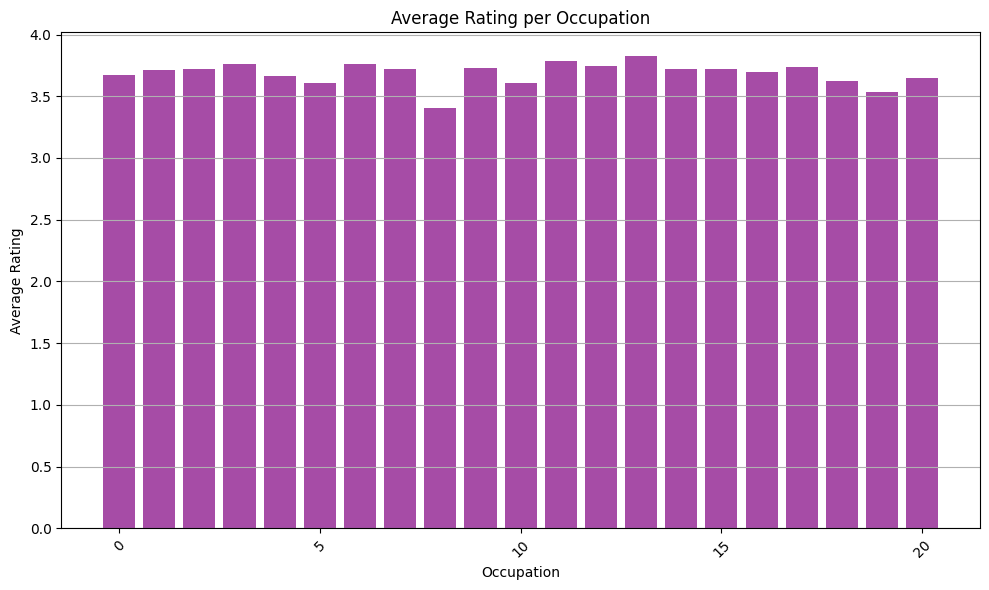

In [29]:
average_ratings = rating_df.groupby('User ID')['Rating'].mean().reset_index()
merged_df = pd.merge(user_df, average_ratings, on='User ID', how='inner')
occ_avg = merged_df.groupby('Occupation')['Rating'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.bar(occ_avg['Occupation'], occ_avg['Rating'], color = 'purple', alpha=0.7)
plt.title('Average Rating per Occupation')
plt.xlabel('Occupation')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Of course, zip code is a categorical variable and its corresponding average rating varies. It may be due to the difference of happiness and expectaion of population in different area.

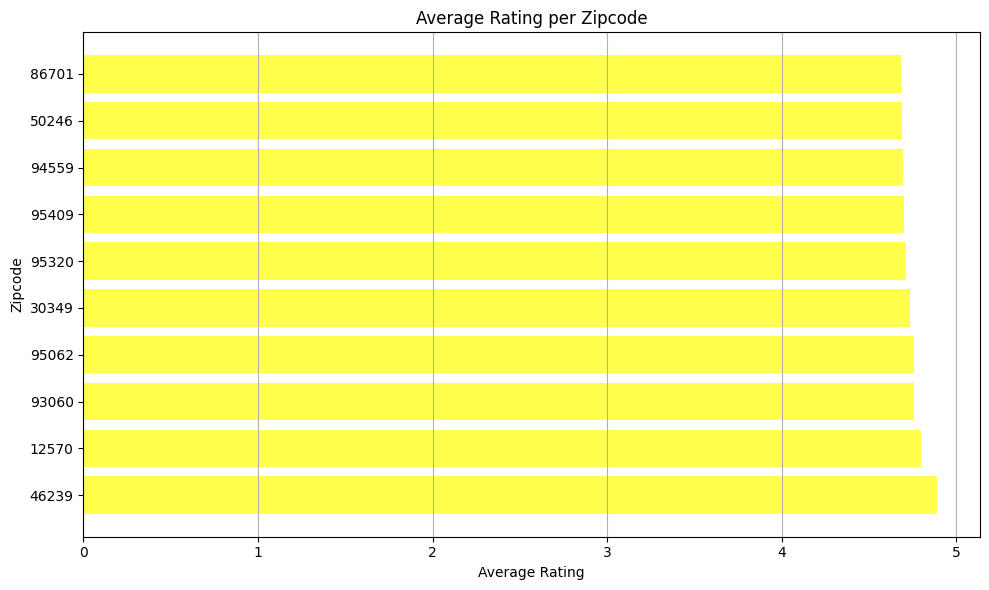

In [30]:
average_ratings = rating_df.groupby('User ID')['Rating'].mean().reset_index()
merged_df = pd.merge(user_df, average_ratings, on='User ID', how='inner')
zip_avg = merged_df.groupby('Zipcode')['Rating'].mean().reset_index()
top_zipcodes = zip_avg.nlargest(10, 'Rating')
plt.figure(figsize=(10, 6))
plt.barh(top_zipcodes['Zipcode'].astype(str), top_zipcodes['Rating'], color='yellow', alpha=0.7)
plt.title('Average Rating per Zipcode')
plt.xlabel('Average Rating')
plt.ylabel('Zipcode')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

From the graph below, we can see that the average rating for the year of movie released has a descending trend. Usually, the average rating given to the movies before 1960s is higher, but with a greater dispersion. This may be explained by a deeper appreciation for certain classic films.

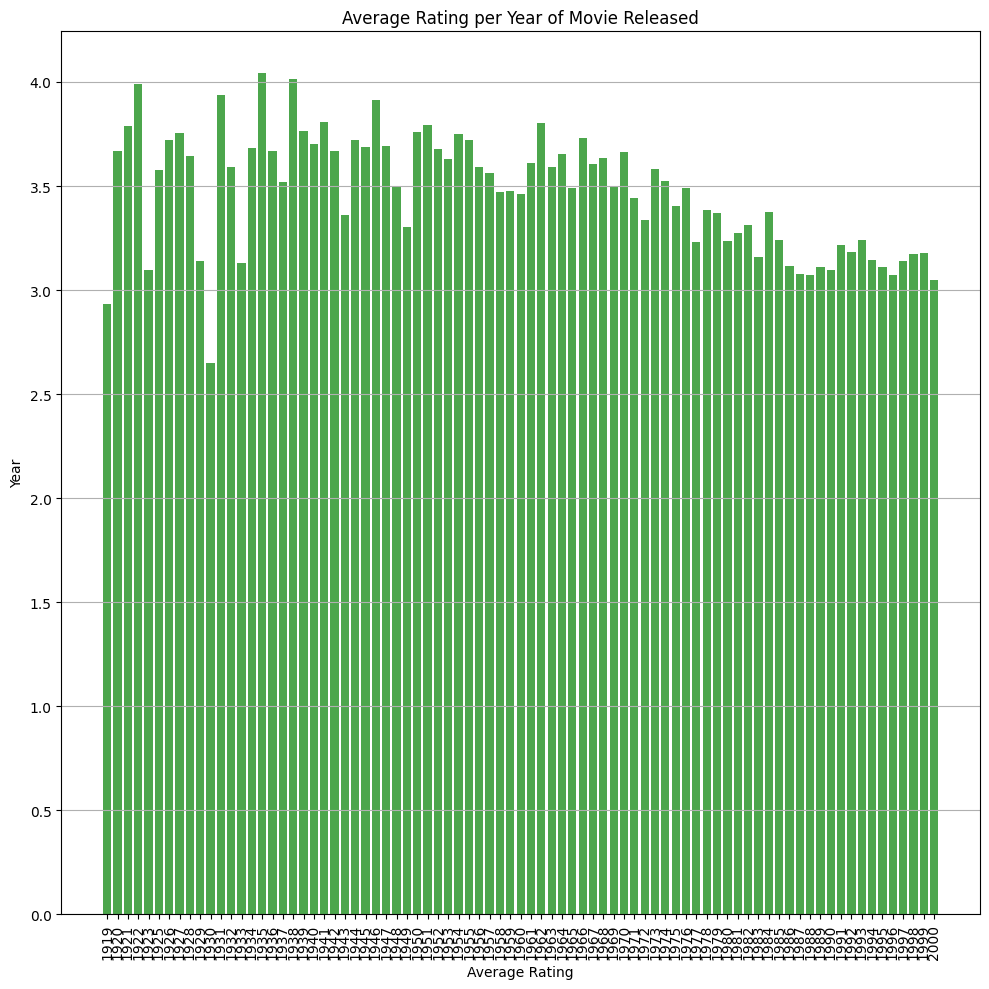

In [31]:
average_ratings = rating_df.groupby('Movie ID')['Rating'].mean().reset_index()
merged_df = pd.merge(movie_df, average_ratings, on='Movie ID', how='inner')
year_avg = merged_df.groupby('Year')['Rating'].mean().reset_index()
plt.figure(figsize=(10, 10))
plt.bar(year_avg['Year'], year_avg['Rating'], color='green', alpha=0.7)
plt.title('Average Rating per Year of Movie Released')
plt.xlabel('Average Rating')
plt.ylabel('Year')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# 5. Data Preprocessing
In the Genres column, each cell contains a list of one to three genres. Hence, an one-hot encoding would be suitable to extract the genres in the dataframe. In addition, standard scaler and label encoder is used for the other continuous variable to improve the performance and categorical variable to convert them into numerical representation respectively.



In [32]:
user_cate = ['User ID', 'Gender', 'Age', 'Occupation', 'Zipcode']
item_cate = ['Movie ID'] # No Genres yet
rating_dense = ['Timestamp']
user_dense = ['User ratings count']
item_dense = ['Year', 'Movie ratings count']
list_cate = ['Genres']
# Handle the list
from sklearn import preprocessing
from sklearn.preprocessing import OneHotEncoder
exploded_genres = df.explode('Genres') # one genre one row
encoder = OneHotEncoder(sparse_output=False) # initialization
encoded_genres = encoder.fit_transform(exploded_genres[['Genres']]) # a number of binary arrays
encoded_df = pd.DataFrame(encoded_genres, columns=encoder.get_feature_names_out(['Genres'])) # add columns name for the arrays
combined_columns = user_cate + item_cate + rating_dense + user_dense + item_dense + ['Rating']
combined_df = exploded_genres[combined_columns].reset_index(drop=True) # get the data of other columns in exploded_genres
final_df = pd.concat([combined_df, encoded_df], axis=1) # combine the "one genre one row" with binary arrays of genres
final_grouped_df = final_df.groupby(combined_columns,
                                     as_index=False).sum() # one rating one row now
df = final_grouped_df
# Dense PP
scaler = preprocessing.StandardScaler()
df[user_dense + item_dense + rating_dense] = scaler.fit_transform(df[user_dense + item_dense + rating_dense])
# Cate PP
encoders = {}
for cate_tmp in user_cate + item_cate:
    ie_tmp = preprocessing.LabelEncoder()
    df[cate_tmp] = ie_tmp.fit_transform(df[cate_tmp])
    encoders[cate_tmp] = ie_tmp
print(df.head(5))

   User ID  Gender  Age  Occupation  Zipcode  Movie ID  Timestamp  \
0        0       0    0          10     1566         0   0.541497   
1        0       0    0          10     1566        47   0.541504   
2        0       0    0          10     1566       144   0.498503   
3        0       0    0          10     1566       253   0.498419   
4        0       0    0          10     1566       513   0.541491   

   User ratings count      Year  Movie ratings count  ...  Genres_Fantasy  \
0            -1.03747  0.578536             1.902234  ...             0.0   
1            -1.03747  0.578536            -0.655172  ...             0.0   
2            -1.03747  0.578536             0.655970  ...             0.0   
3            -1.03747 -0.675879             3.281272  ...             1.0   
4            -1.03747  0.439156             2.244730  ...             0.0   

   Genres_Film-Noir  Genres_Horror  Genres_Musical  Genres_Mystery  \
0               0.0            0.0             0.0  

In [33]:
df.shape

(1000209, 29)

In [34]:
genre_list = list(encoder.get_feature_names_out(['Genres']))
print(genre_list)

['Genres_Action', 'Genres_Adventure', 'Genres_Animation', "Genres_Children's", 'Genres_Comedy', 'Genres_Crime', 'Genres_Documentary', 'Genres_Drama', 'Genres_Fantasy', 'Genres_Film-Noir', 'Genres_Horror', 'Genres_Musical', 'Genres_Mystery', 'Genres_Romance', 'Genres_Sci-Fi', 'Genres_Thriller', 'Genres_War', 'Genres_Western']


In [35]:
for genre in genre_list:
    df[genre] = df[genre].astype(int) # Convert all output of OneHotEncoder into integers

I split the data into training and testing datasets, with the testing set comprising one-third of the total data.

In [36]:
# create train/test datasets
import numpy as np
item_cate = item_cate + genre_list
from sklearn.model_selection import train_test_split
train, test = train_test_split(df,
                               test_size=0.33,
                               random_state=42)
UD_train, UC_train = train[user_dense].values.astype(np.float32), train[user_cate].values
ID_train, IC_train = train[item_dense].values.astype(np.float32), train[item_cate].values
RD_train = train[rating_dense].values.astype(np.float32)
UD_test, UC_test = test[user_dense].values.astype(np.float32), test[user_cate].values
ID_test, IC_test = test[item_dense].values.astype(np.float32), test[item_cate].values
RD_test = test[rating_dense].values.astype(np.float32)
y_train = train['Rating'].values.astype(np.float32)
y_test = test['Rating'].values.astype(np.float32)


# 6. Model Building
I have decided to use neural network matrix factorization as a basis for the model. All categorical variables will be put into embedding layers to produce latent factor vectors. Then, the categorical latent factor vectors and continuous variables will be concatenated within user or item categories. Noted that the timestamp of the rating given itself counts as another category. After that, these 3 dataframes will be put into the dense layers respectively, with a ReLU function operation. Next, the user output and timestamp outout will be concatenated together and put into a dense layer to get the user final output. The reason behind this layer is that users will give out ratings at different timestamps, so it is not user-specific side information. However, the rating given out at a certain timestamp depends on the users itself, instead of the item. Finally, the user final output will be concatenated with item output together to pass the dense layer is used to obtain the final output. This adjusted Double Tower Recommender System Model could learn the interactions between different variables, but also balance the complexity of the model.

In [37]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

class DTowerRS(keras.Model):
    def __init__(self, num_users, num_items, num_gender, num_age,
                 num_occ, num_zip,
                 embedding_size, dense_size, genre_list, **kwargs): # no num_specific_genre as too many and it should be 2 for each
        super(DTowerRS, self).__init__(**kwargs)
        self.num_users = num_users
        self.num_items = num_items
        self.num_gender = num_gender
        self.num_age = num_age
        self.num_occ = num_occ
        self.num_zip = num_zip
        self.embedding_size = embedding_size
        self.dense_size = dense_size
        self.genre_list = genre_list


        # Embedding layers
        self.embeddings = {
            'user': layers.Embedding(num_users, embedding_size),
            'item': layers.Embedding(num_items, embedding_size),
            'gender': layers.Embedding(num_gender, embedding_size),
            'age': layers.Embedding(num_age, embedding_size),
            'occupation': layers.Embedding(num_occ, embedding_size),
            'zipcode': layers.Embedding(num_zip, embedding_size),
        }
        for genre in self.genre_list:
            self.embeddings[genre] = layers.Embedding(2, embedding_size)

        # concate
        self.concate = layers.Concatenate()


        # More Mapping layers
        self.user_dense = layers.Dense(dense_size,
                                       activation='relu')
        self.item_dense = layers.Dense(dense_size,
                                       activation='relu')
        self.rate_dense = layers.Dense(dense_size,
                                       activation='relu')
        self.user_final_dense = layers.Dense(dense_size,
                                             activation='relu')
        self.joint_dense = layers.Dense(dense_size,
                                       activation='relu')
        self.dense_out = layers.Dense(1)




    def call(self, inputs):
        # multi source inputs: cate/cont data
        UD_feat, ID_feat, UC_feat, IC_feat, RD_feat = inputs[0], inputs[1], inputs[2], inputs[3], inputs[4]


        # user embedding
        user_vec = self.embeddings['user'](UC_feat[:,0])
        gender_vec = self.embeddings['gender'](UC_feat[:,1])
        age_vec = self.embeddings['age'](UC_feat[:,2])
        occ_vec = self.embeddings['occupation'](UC_feat[:,3])
        zip_vec = self.embeddings['zipcode'](UC_feat[:,4])

        # item embedding
        item_vec = self.embeddings['item'](IC_feat[:,0])
        genre_vectors = []
        for i, genre in enumerate(self.genre_list):
            # Use the one-hot encoded input to gather genre vectors
            genre_vector = self.embeddings[genre](IC_feat[:, i + 1])  # Assuming genres start from index 1
            genre_vectors.append(genre_vector)

        # concate all feats
        user_all_vec = self.concate([UD_feat,
                                     user_vec,
                                     gender_vec,
                                     age_vec,
                                     occ_vec,
                                     zip_vec])
        item_all_vec = self.concate([ID_feat, item_vec] + genre_vectors)


        user_dense_vec = self.user_dense(user_all_vec)
        item_dense_vec = self.item_dense(item_all_vec)
        rate_dense_vec = self.rate_dense(RD_feat)

        # user final dense
        user_final_vec = self.concate([user_dense_vec, rate_dense_vec])
        user_final_out = self.user_final_dense(user_final_vec)

        # joint dense
        joint_vec = self.concate([user_final_vec, item_dense_vec])
        joint_out = self.joint_dense(joint_vec)


        # out
        out = self.dense_out(joint_out)


        return out


# 7. Model Fitting


In [38]:
num_users = max(max(UC_train[:,0]), max(UC_test[:,0])) + 1
num_gender = max(max(UC_train[:,1]), max(UC_test[:,1])) + 1
num_age = max(max(UC_train[:,2]), max(UC_test[:,2])) + 1
num_occ = max(max(UC_train[:,3]), max(UC_test[:,3])) + 1
num_zip = max(max(UC_train[:,4]), max(UC_test[:,4])) + 1

num_items = max(max(IC_train[:,0]), max(IC_train[:,0])) + 1

In [39]:
print([num_users,num_items, num_gender, num_age,
                 num_occ, num_zip])

[np.int64(6040), np.int64(3706), np.int64(2), np.int64(7), np.int64(21), np.int64(3403)]


In [40]:
IC_train

array([[1886,    0,    0, ...,    0,    1,    0],
       [ 396,    0,    0, ...,    0,    0,    0],
       [ 467,    0,    0, ...,    1,    0,    0],
       ...,
       [1563,    0,    0, ...,    0,    0,    0],
       [1109,    0,    0, ...,    0,    0,    0],
       [1553,    1,    0, ...,    0,    0,    0]])

In this model, it aims at minimizing mean squared error with an adam optimizer. Metrics of mean absolute error and root mean squared error are used for monitoring the loss on the training data. To avoid overfitting, 5 epochs of validation loss increases will terminate the model in advance.

In [41]:
model = DTowerRS(num_users=num_users,
                 num_items=num_items,
                 num_gender=num_gender,
                 num_age=num_age,
                 num_occ=num_occ,
                 num_zip=num_zip,
                 genre_list=genre_list,
                 embedding_size=100,
                 dense_size=128)


metrics = [
    keras.metrics.MeanAbsoluteError(name='mae'),
    keras.metrics.RootMeanSquaredError(name='rmse')
]


model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=metrics
)
# model training
callbacks = [keras.callbacks.EarlyStopping(
    monitor='val_rmse', min_delta=0, patience=5, verbose=1,
    mode='min', baseline=None, restore_best_weights=True)]


history = model.fit(
    x=[UD_train, ID_train, UC_train, IC_train, RD_train],
    y=y_train,
    batch_size=64,
    epochs=50,
    verbose=1,
    validation_split=.2,
    callbacks=callbacks
)
model.summary()
model.evaluate([UD_test, ID_test, UC_test, IC_test, RD_test], y_test)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['d_tower_rs/dense_3/kernel', 'd_tower_rs/dense_3/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


8377/8377 ━━━━━━━━━━━━━━━━━━━━ 128s 15ms/step - loss: 0.9940 - mae: 0.7845 - rmse: 0.9902 - val_loss: 0.8320 - val_mae: 0.7141 - val_rmse: 0.9121
Epoch 2/50
8377/8377 ━━━━━━━━━━━━━━━━━━━━ 121s 12ms/step - loss: 0.8166 - mae: 0.7138 - rmse: 0.9036 - val_loss: 0.8086 - val_mae: 0.7048 - val_rmse: 0.8992
Epoch 3/50
8377/8377 ━━━━━━━━━━━━━━━━━━━━ 150s 13ms/step - loss: 0.7846 - mae: 0.6973 - rmse: 0.8858 - val_loss: 0.7985 - val_mae: 0.7060 - val_rmse: 0.8936
Epoch 4/50
8377/8377 ━━━━━━━━━━━━━━━━━━━━ 96s 11ms/step - loss: 0.7726 - mae: 0.6919 - rmse: 0.8790 - val_loss: 0.7921 - val_mae: 0.6996 - val_rmse: 0.8900
Epoch 5/50
8377/8377 ━━━━━━━━━━━━━━━━━━━━ 100s 12ms/step - loss: 0.7581 - mae: 0.6845 - rmse: 0.8707 - val_loss: 0.7894 - val_mae: 0.6953 - val_rmse: 0.8885
Epoch 6/50
8377/8377 ━━━━━━━━━━━━━━━━━━━━ 148s 13ms/step - loss: 0.7480 - mae: 0.6791 - rmse: 0.8648 - val_loss: 0.7827 - val_mae: 0.6931 - val_rmse: 0.8847
Epoch 7/50
8377/8377 ━━━━━━━━━━━━━━━━━━━━ 128s 11ms/step - loss: 0.736

Model: "d_tower_rs"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100)            │       604,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 100)            │       370,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 100)            │           700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 100)            │         2,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 100)            │       340,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_6 (Embedding)         │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_8 (Embedding)         │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_9 (Embedding)         │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_10 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_11 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_12 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_13 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_14 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_15 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_16 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_17 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_18 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_19 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_20 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_21 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_22 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_23 (Embedding)        │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concatenate (Concatenate)       │ (None, 501)            │             

...

 Trainable params: 1,711,901 (6.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,423,804 (13.06 MB)

10315/10315 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.7786 - mae: 0.6933 - rmse: 0.8824


[0.7802424430847168, 0.6937748789787292, 0.8833133578300476]

In [42]:
import pickle

# Save the model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)


# 8. Model Forecasting
To do a model forecasting, we can make use of the first ten users data, merged with the movies data. This allow us to forecast the favourite movie for them.

The latestest timestamp + 1 is used as it is a new information we have to think of. Then, we can make use of the previously used encoder, standard scaler to ensure the inputs are accurate and match with the training data. By finding out the highest forecast rating, we can predict the favourite movie of each user, and make it as an recommendation.

Please be reminded that some labels are not available as some movies don't have rating in the list. Our model failed to forecast these "cold-start items".

In [43]:
pred_df = pd.merge(user_df, movie_df, how='cross')
pred_df = pred_df[pred_df['User ID'] <= 10]
pred_df.shape

(38830, 10)

In [44]:
max_timestamp = rating_df['Timestamp'].max()
pred_df['Timestamp'] = max_timestamp + 1

In [45]:
pred_df.head(5)

,User ID,Gender,Age,Occupation,Zipcode,User ratings count,Movie ID,Genres,Year,Movie ratings count,Timestamp
0,1,F,1,10,48067,53,1,"[Animation, Children's, Comedy]",1995,2077,1046454591
1,1,F,1,10,48067,53,2,"[Adventure, Children's, Fantasy]",1995,701,1046454591
2,1,F,1,10,48067,53,3,"[Comedy, Romance]",1995,478,1046454591
3,1,F,1,10,48067,53,4,"[Comedy, Drama]",1995,170,1046454591
4,1,F,1,10,48067,53,5,[Comedy],1995,296,1046454591


In [46]:
pred_exploded_genres = pred_df.explode('Genres') # one genre one row
pred_encoded_genres = encoder.transform(pred_exploded_genres[['Genres']]) # a number of binary arrays
pred_encoded_df = pd.DataFrame(pred_encoded_genres, columns=encoder.get_feature_names_out(['Genres'])) # add columns name for the arrays
pred_combined_columns = [col for col in combined_columns if col not in genre_list and col != 'Rating']
pred_combined_df = pred_exploded_genres[pred_combined_columns].reset_index(drop=True) # get the data of other columns in exploded_genres
pred_final_df = pd.concat([pred_combined_df, pred_encoded_df], axis=1) # combine the "one genre one row" with binary arrays of genres
pred_final_grouped_df = pred_final_df.groupby(pred_combined_columns,
                                     as_index=False).sum() # one user for one movie one row now
pred_df = pred_final_grouped_df
# Dense PP
pred_df[user_dense + item_dense + rating_dense] = scaler.transform(pred_df[user_dense + item_dense + rating_dense])
# Cate PP
item_cate = [item for item in item_cate if item not in genre_list]
for cate_tmp in user_cate + item_cate:
    known_classes = set(encoders[cate_tmp].classes_) # Get the set of known classes from the encoder
    unseen_mask = ~pred_df[cate_tmp].isin(known_classes) # Identify rows with unseen labels
    pred_df = pred_df[~unseen_mask]  # Keep only rows with known labels
    pred_df[cate_tmp] = encoders[cate_tmp].transform(pred_df[cate_tmp]) # Transform the remaining rows

print(pred_df.head(5))

   User ID  Gender  Age  Occupation  Zipcode  Movie ID  Timestamp  \
0        0       0    0          10     1566         0    6.10661   
1        0       0    0          10     1566         1    6.10661   
2        0       0    0          10     1566         2    6.10661   
3        0       0    0          10     1566         3    6.10661   
4        0       0    0          10     1566         4    6.10661   

   User ratings count      Year  Movie ratings count  ...  Genres_Fantasy  \
0            -1.03747  0.578536             1.902234  ...             0.0   
1            -1.03747  0.578536            -0.173867  ...             1.0   
2            -1.03747  0.578536            -0.510328  ...             0.0   
3            -1.03747  0.578536            -0.975036  ...             0.0   
4            -1.03747  0.578536            -0.784928  ...             0.0   

   Genres_Film-Noir  Genres_Horror  Genres_Musical  Genres_Mystery  \
0               0.0            0.0             0.0  

In [47]:
item_cate = item_cate + genre_list
UD_pred, UC_pred = pred_df[user_dense].values.astype(np.float32), pred_df[user_cate].values
ID_pred, IC_pred = pred_df[item_dense].values.astype(np.float32), pred_df[item_cate].values
RD_pred = pred_df[rating_dense].values.astype(np.float32)

In [48]:
print(UD_train.shape, ID_train.shape, UC_train.shape, IC_train.shape, RD_train.shape)

(670140, 1) (670140, 2) (670140, 5) (670140, 19) (670140, 1)


In [49]:
print(UD_pred.shape, ID_pred.shape, UC_pred.shape, IC_pred.shape, RD_pred.shape)

(37060, 1) (37060, 2) (37060, 5) (37060, 19) (37060, 1)


In [50]:
pred_data = [UD_pred, ID_pred, UC_pred, IC_pred, RD_pred]
for pre in pred_data:
   print(np.isnan(pre).any(), np.isinf(pre).any())

False False
False False
False False
False False
False False


In [51]:
pred = model.predict([UD_pred, ID_pred, UC_pred, IC_pred, RD_pred])
num_rows = int(pred_df.shape[0]/10)
best_movie = np.zeros(10)
for i in range(1, 11):
    best_movie[i - 1] = np.argmax(pred[(i - 1) * num_rows:(i * num_rows - 1)]) # Return Movie ID


1159/1159 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [52]:
best_movie

array([2016., 2557., 2016., 2309.,  862., 2016., 2016., 1839., 2698.,
       2016.])

# 9. Conclusion
The Neural Network Matrix Factorization Method with side information Recommendation System can make use of tensorflow keras deep learning model to capture the pattern and givean accurate and logical recommendation to a new customer. In addition, Matrix Factorization can incorporate user-specific and movie-specific characteristics interactions into consideration. Experiments found that it could greatly reduce the mean squared error. Moreover, side information allows us the predict the preference of cold-start user and the attractiveness of cold-start item. Although the above model is unavailable to predict these issues, we can fix the issue by dropping out the user ID and movie ID to train the model.